In [1]:
# ============================================
# 고려사항 1번 - 관광특구 외국인 vs 직장인 충돌 해결
# 목적: 외국인=매출 규모 / 직장인=상권 기초 체력 역할 분담 증명
# 방법: 평일 음식점 vs 주말 패션·뷰티 매출 비중 분리
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 외국인 추정매출 로드
df_외국인 = pd.read_csv(
    '../data/외부데이터/서울시_외국인_추정매출액_통합.csv',
    encoding='utf-8'
)

# 내국인 추정매출 로드
df_내국인 = pd.read_csv(
    '../data/외부데이터/서울시_내국인_추정매출액_통합.csv',
    encoding='utf-8'
)

print(f'외국인 매출: {df_외국인.shape}')
print(f'내국인 매출: {df_내국인.shape}')
print()
print(df_외국인.head(3))

외국인 매출: (2976, 9)
내국인 매출: (2989, 9)

   자치구   행정동 업종_대분류  2020_매출액(천원)  2021_매출액(천원)  2022_매출액(천원)  2023_매출액(천원)  \
0  도봉구  도봉1동    쇼핑업     39624.624     36542.924     52840.128     68428.996   
1  도봉구  도봉1동    숙박업       442.026       348.440       430.464       511.270   
2  도봉구  도봉1동   식음료업     17861.805     24199.840     40970.976     52592.526   

   2024_매출액(천원)  2025_매출액(천원)  
0      80499.52     51789.815  
1        450.00       652.190  
2      63597.12     51387.545  


In [2]:
print('업종 대분류:')
print(df_외국인['업종_대분류'].unique())
print()
print('자치구:')
print(df_외국인['자치구'].unique())

업종 대분류:
<StringArray>
['쇼핑업', '숙박업', '식음료업', '여가서비스업', '여행업', '운송업', '의료웰니스업']
Length: 7, dtype: str

자치구:
<StringArray>
[ '도봉구',  '노원구',  '금천구',  '구로구',  '광진구',  '관악구',  '강서구',  '강북구',  '강동구',
  '강남구', '영등포구',  '양천구',  '송파구',  '성북구',  '성동구',  '서초구', '서대문구',  '마포구',
  '동작구', '동대문구',  '중랑구',   '중구',  '종로구',  '은평구',  '용산구']
Length: 25, dtype: str


In [4]:
# ============================================
# 관광특구 자치구 (중구·종로구·용산구) 필터링
# ============================================

관광특구_구 = ['중구', '종로구', '용산구']

# 외국인 관광특구 필터링
외국인_관광 = df_외국인[df_외국인['자치구'].isin(관광특구_구)].copy()

# 내국인 관광특구 필터링
내국인_관광 = df_내국인[df_내국인['자치구'].isin(관광특구_구)].copy()

# 연도별 컬럼 합산 (2020~2024)
연도_컬럼 = ['2020_매출액(천원)', '2021_매출액(천원)', '2022_매출액(천원)', 
             '2023_매출액(천원)', '2024_매출액(천원)']

# 업종별 총매출 합산
외국인_업종 = 외국인_관광.groupby('업종_대분류')[연도_컬럼].sum().sum(axis=1)
내국인_업종 = 내국인_관광.groupby('업종_대분류')[연도_컬럼].sum().sum(axis=1)

# 비중 계산
외국인_비중 = (외국인_업종 / 외국인_업종.sum() * 100).round(1)
내국인_비중 = (내국인_업종 / 내국인_업종.sum() * 100).round(1)

print('관광특구 외국인 업종별 매출 비중')
print(외국인_비중.sort_values(ascending=False))
print()
print('관광특구 내국인 업종별 매출 비중')
print(내국인_비중.sort_values(ascending=False))

관광특구 외국인 업종별 매출 비중
업종_대분류
쇼핑업       47.0
숙박업       25.3
식음료업      11.7
의료웰니스업     7.3
운송업        4.8
여가서비스업     3.7
여행업        0.3
dtype: float64

관광특구 내국인 업종별 매출 비중
업종_대분류
운송업       37.8
식음료업      29.1
쇼핑업       26.7
숙박업        3.5
의료웰니스업     1.4
여가서비스업     0.9
여행업        0.6
dtype: float64


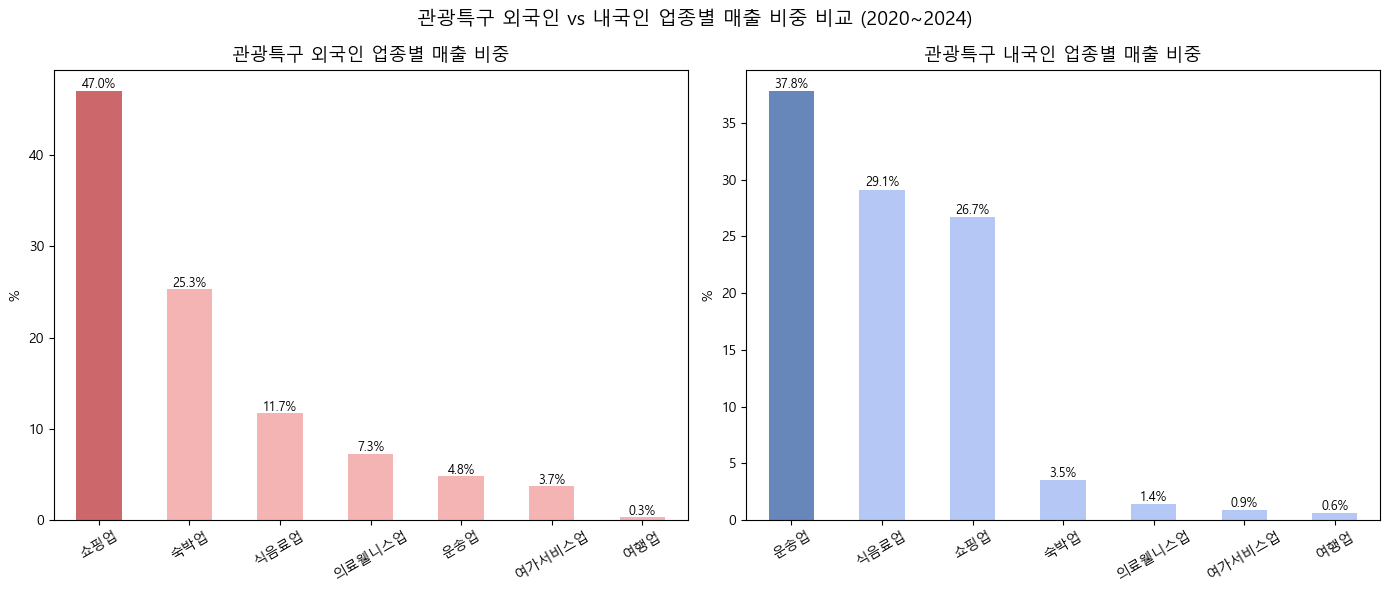

In [6]:
# ============================================
# 외국인 vs 내국인 업종별 매출 비중 비교 그래프
# ============================================

# 그래프 2개 배치 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 외국인 막대 색상 설정
# 가장 높은 값은 진한 빨강, 나머지는 연한 빨강
colors_외 = ['#C44E52' if v == 외국인_비중.max() else '#F4A7A7' 
             for v in 외국인_비중.sort_values(ascending=False)]

# 내국인 막대 색상 설정
# 가장 높은 값은 진한 파랑, 나머지는 연한 파랑
colors_내 = ['#4C72B0' if v == 내국인_비중.max() else '#A7BEF4' 
             for v in 내국인_비중.sort_values(ascending=False)]

# 외국인 그래프 (왼쪽)
외국인_비중.sort_values(ascending=False).plot(
    kind='bar',     # 막대그래프
    ax=axes[0],     # 왼쪽 축에 그리기
    color=colors_외, 
    alpha=0.85      # 투명도
)
axes[0].set_title('관광특구 외국인 업종별 매출 비중', fontsize=13)
axes[0].set_ylabel('%')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)  # x축 라벨 30도 기울이기

# 막대 위에 수치 표시
for i, v in enumerate(외국인_비중.sort_values(ascending=False)):
    axes[0].text(i, v + 0.3, f'{v}%', ha='center', fontsize=9)

# 내국인 그래프 (오른쪽)
내국인_비중.sort_values(ascending=False).plot(
    kind='bar',
    ax=axes[1],     # 오른쪽 축에 그리기
    color=colors_내,
    alpha=0.85
)
axes[1].set_title('관광특구 내국인 업종별 매출 비중', fontsize=13)
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

# 막대 위에 수치 표시
for i, v in enumerate(내국인_비중.sort_values(ascending=False)):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontsize=9)

# 전체 제목
plt.suptitle('관광특구 외국인 vs 내국인 업종별 매출 비중 비교 (2020~2024)', fontsize=14)
plt.tight_layout()  # 그래프 간격 자동 조정
plt.show()